In [20]:
import sys
import pandas as pd
import numpy as np
import sklearn

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: d:\Documents\ML\Bank_Mark_Classification\.venv\Scripts\python.exe
Pandas: 3.0.5
NumPy: 2.5.2
Scikit-learn: 1.9.0


# Bank Marketing Intelligence System
## 01 — Data Understanding 
This notebook focuses on understanding the Bank Marketing dataset before any machine learning is performed.

In [21]:
import numpy as np
import pandas as pd

In [22]:
df = pd.read_csv("D:/Documents/ML/Bank_Mark_Classification/data/raw/bank-full.csv", sep = ";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [23]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [24]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [25]:
df.shape

(45211, 17)

In [26]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


## 2.1 Dataset Cardinality and Target Distribution

In [28]:
df.nunique().sort_values()

housing         2
loan            2
default         2
y               2
contact         3
marital         3
poutcome        4
education       4
month          12
job            12
day            31
previous       41
campaign       48
age            77
pdays         559
duration     1573
balance      7168
dtype: int64

In [29]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [30]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [31]:
uk_counts = (df == "unknown").sum()
uk_counts[uk_counts > 0].sort_values(ascending=False)

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
# unknown percentages

unknown_counts = (df == "unknown").sum()

unknown_summary = pd.DataFrame({
    "unknown_count": unknown_counts[unknown_counts > 0]
})

unknown_summary["percentage"] = (
    unknown_summary["unknown_count"] / len(df) * 100
)

unknown_summary.sort_values("unknown_count", ascending=False)

,unknown_count,percentage
poutcome,36959,81.747805
contact,13020,28.798301
education,1857,4.107407
job,288,0.637013


In [34]:
# Numerical statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [35]:
# Skewness

df.select_dtypes(include="number").skew().sort_values(ascending=False)

previous    41.846454
balance      8.360308
campaign     4.898650
duration     3.144318
pdays        2.615715
age          0.684818
day          0.093079
dtype: float64

In [36]:
# job vs target

df.groupby("job")["y"].value_counts(normalize=True)

job            y  
admin.         no     0.877973
               yes    0.122027
blue-collar    no     0.927250
               yes    0.072750
entrepreneur   no     0.917283
               yes    0.082717
housemaid      no     0.912097
               yes    0.087903
management     no     0.862444
               yes    0.137556
retired        no     0.772085
               yes    0.227915
self-employed  no     0.881571
               yes    0.118429
services       no     0.911170
               yes    0.088830
student        no     0.713220
               yes    0.286780
technician     no     0.889430
               yes    0.110570
unemployed     no     0.844973
               yes    0.155027
unknown        no     0.881944
               yes    0.118056
Name: proportion, dtype: float64

In [37]:
# Education vs target

df.groupby("education")["y"].value_counts(normalize=True)

education  y  
primary    no     0.913735
           yes    0.086265
secondary  no     0.894406
           yes    0.105594
tertiary   no     0.849936
           yes    0.150064
unknown    no     0.864297
           yes    0.135703
Name: proportion, dtype: float64

## 2.2 Target Distribution

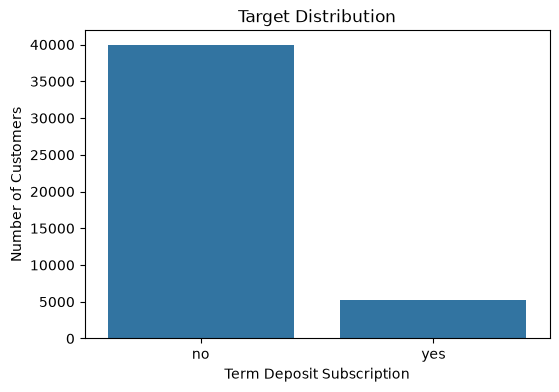

In [ ]:
# Target imbalance

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y")

plt.title("Target Distribution")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")

plt.show()

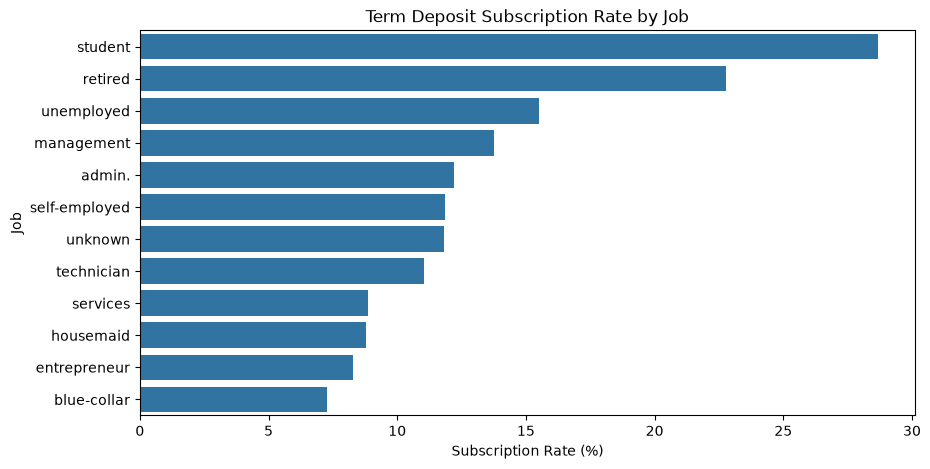

In [ ]:
# Subscription rate by job

job_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("job")["subscribed"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=job_subscription.values * 100,
    y=job_subscription.index
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.show()

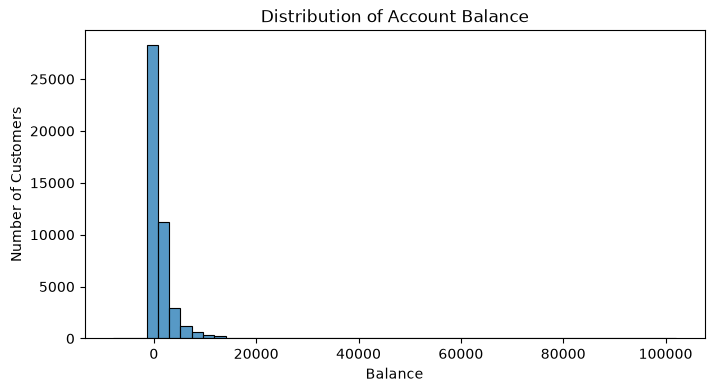

In [ ]:
# Balance distribution

plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="balance", bins=50)

plt.title("Distribution of Account Balance")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.show()

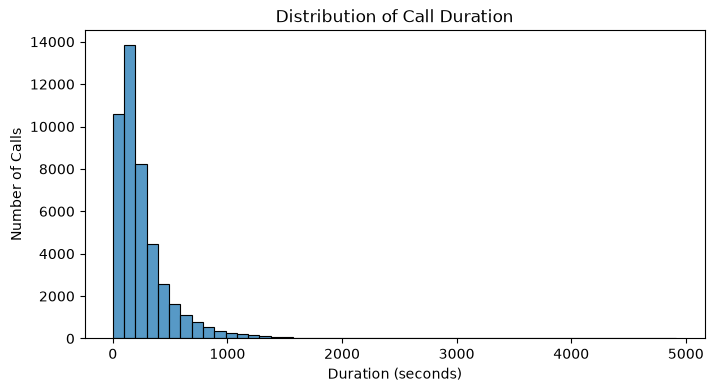

In [41]:
# Duration

plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="duration", bins=50)

plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Calls")

plt.show()

In [42]:
df.groupby("y")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


In [43]:
duration_by_target = (
    df.groupby("y")["duration"]
      .mean()
)

duration_by_target

y
no     221.182806
yes    537.294574
Name: duration, dtype: float64

In [44]:
df.groupby("y")["duration"].median()

y
no     164.0
yes    426.0
Name: duration, dtype: float64

## Day 1 Findings

### Dataset
- 45,211 customer records
- 17 columns: 16 features and 1 binary target
- Target: `y`, indicating term-deposit subscription

### Target imbalance
- `no`: 39,922 (88.30%)
- `yes`: 5,289 (11.70%)
- The dataset is significantly imbalanced, so accuracy alone is not an appropriate evaluation metric.

### Data quality
- No exact duplicate rows were found.
- No Pandas-level null values were present.
- Several categorical variables contain the explicit value `unknown`, with particularly high frequency in `poutcome` (81.75%) and `contact` (28.80%).
- `pdays = -1` appears frequently and should be treated according to its business meaning rather than as a conventional numerical outlier.

### Feature distributions
- `previous`, `balance`, `campaign`, `duration`, and `pdays` are strongly right-skewed.
- `balance` contains both negative and very large positive values.
- `previous` has a median of 0 but a maximum of 275.
- `pdays` has a median of -1, indicating that -1 represents a meaningful special state.

### Duration leakage investigation
`duration` shows a strong relationship with the target:
- Mean duration for `no`: 221 seconds
- Mean duration for `yes`: 537 seconds
- Median duration for `no`: 164 seconds
- Median duration for `yes`: 426 seconds

Although `duration` is highly predictive, it is not available before the marketing call is made. Therefore, using it for pre-call customer targeting would create a deployment-time information mismatch.

The project will therefore compare:
1. A benchmark model including `duration`
2. A deployment-realistic model excluding `duration`

The deployment-realistic model will be preferred for the actual targeting use case.